In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns

In [2]:
df = pd.read_csv("../data/train.csv")

In [3]:
df["MonthlyIncome"]

0       253905.0
1       404475.0
2       278145.0
3       326805.0
4       258435.0
          ...   
3484    258900.0
3485    260415.0
3486    317340.0
3487    527910.0
3488    278190.0
Name: MonthlyIncome, Length: 3489, dtype: str

In [4]:
pd.unique(df['MonthlyIncome'].values.ravel())

<StringArray>
['253905.0', '404475.0', '278145.0', '326805.0', '258435.0', '月収26.0万円',
 '453180.0', '261900.0', '247800.0', '257610.0',
 ...
 '434145.0', '318315.0', '263850.0', '333135.0', '320490.0', '258900.0',
 '260415.0', '317340.0', '527910.0', '278190.0']
Length: 2543, dtype: str

In [5]:
df['MonthlyIncome']

0       253905.0
1       404475.0
2       278145.0
3       326805.0
4       258435.0
          ...   
3484    258900.0
3485    260415.0
3486    317340.0
3487    527910.0
3488    278190.0
Name: MonthlyIncome, Length: 3489, dtype: str

In [6]:
def clean_income(x):
    x_str = str(x)
    if '万円' in x_str:
        return float(x_str.replace('月収', '').replace('万円', '')) * 10000
    return float(x_str.replace('月収', '').replace('万円', ''))
df['MonthlyIncome'] = df['MonthlyIncome'].apply(clean_income)

In [7]:
df['MonthlyIncome'].value_counts()

MonthlyIncome
300000.0    185
400000.0    126
500000.0     36
350000.0     23
310000.0     22
           ... 
258900.0      1
260415.0      1
317340.0      1
527910.0      1
278190.0      1
Name: count, Length: 2541, dtype: int64

0（買わなかった人）と1（買った人）で、どの収入層にどれくらい人がいるか

In [8]:
df['MonthlyIncome']

0       253905.0
1       404475.0
2       278145.0
3       326805.0
4       258435.0
          ...   
3484    258900.0
3485    260415.0
3486    317340.0
3487    527910.0
3488    278190.0
Name: MonthlyIncome, Length: 3489, dtype: float64

# データ全体の年収グラフ

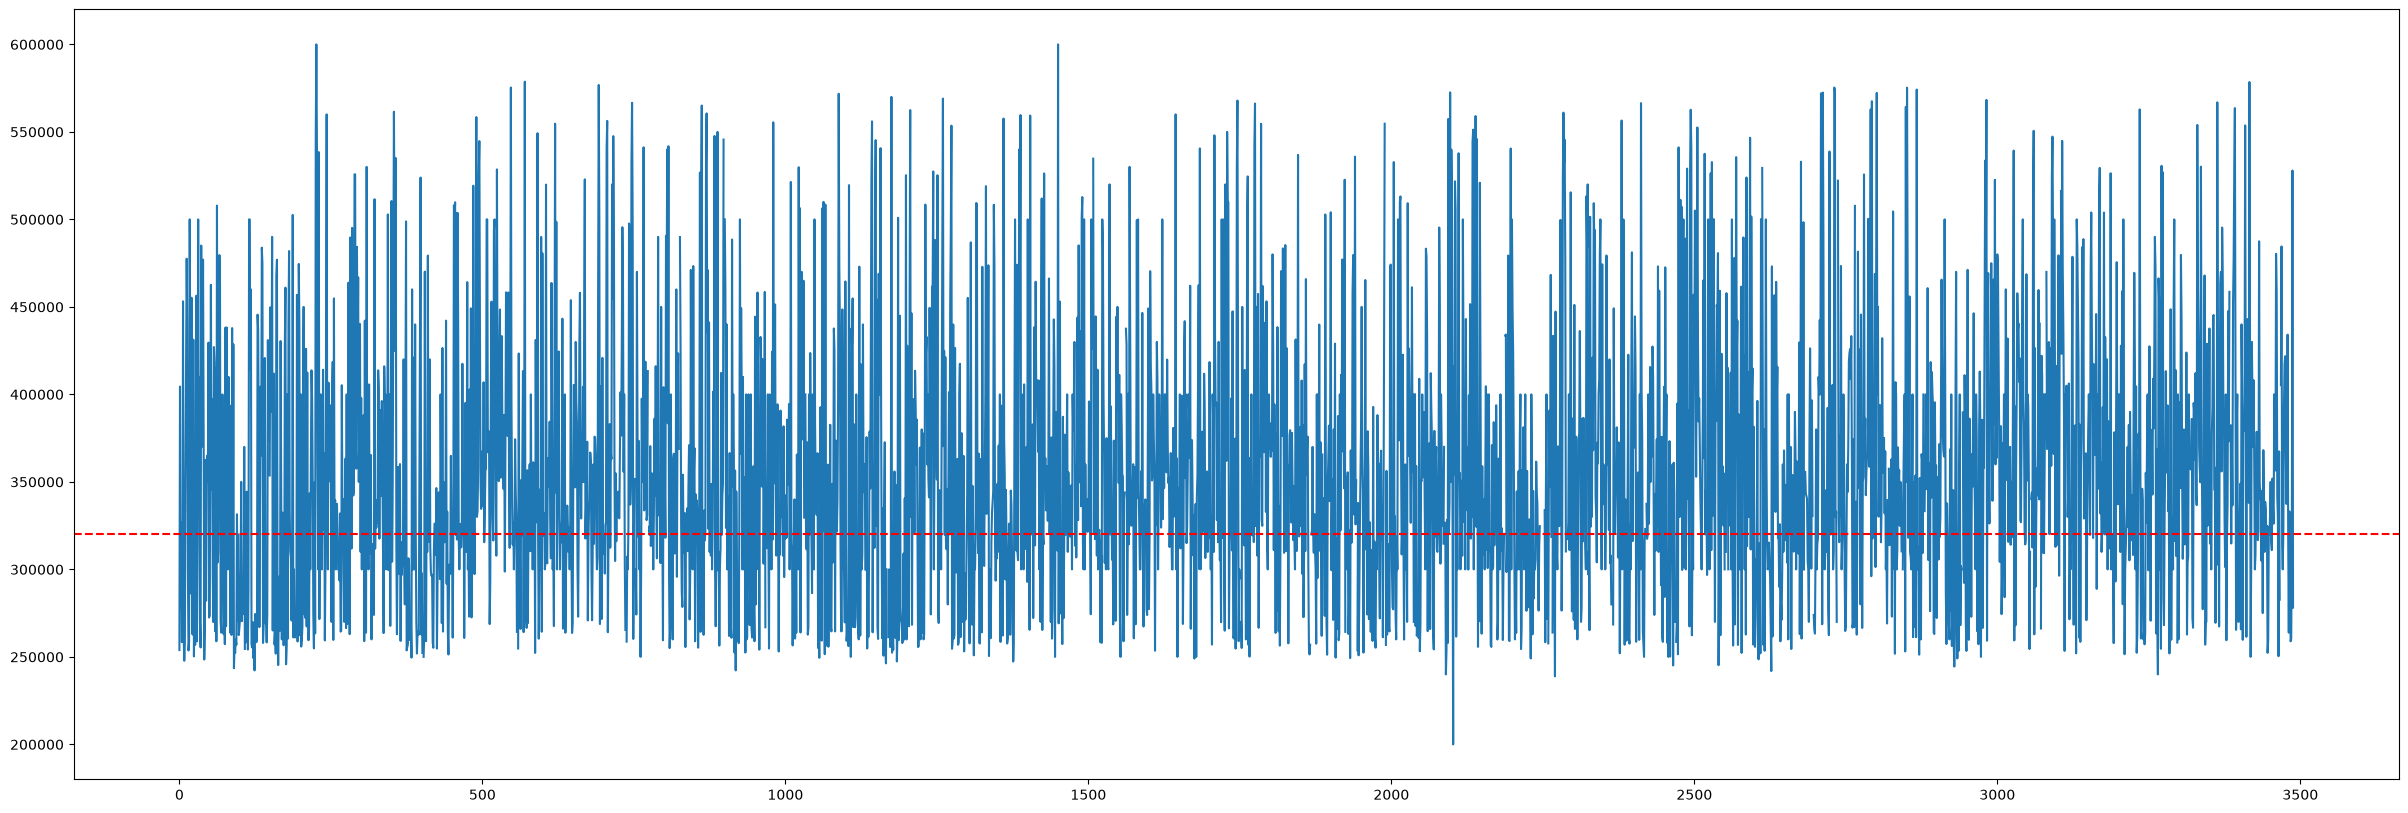

In [9]:
plt.figure(figsize=(30, 10))
plt.plot(df['MonthlyIncome'])
plt.axhline(y=320000, color='red', linestyle='--')
plt.show()

* 30万～35万くらいが多い、ラインは層が多い32万前後

# 成約した（してない）人と年収の関係性

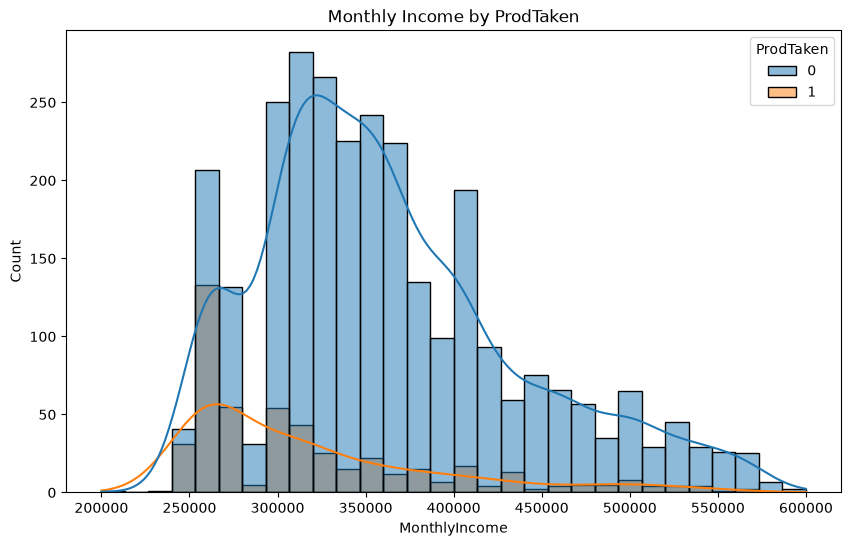

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyIncome', hue='ProdTaken', kde=True, bins=30)
plt.title('Monthly Income by ProdTaken')
plt.show()

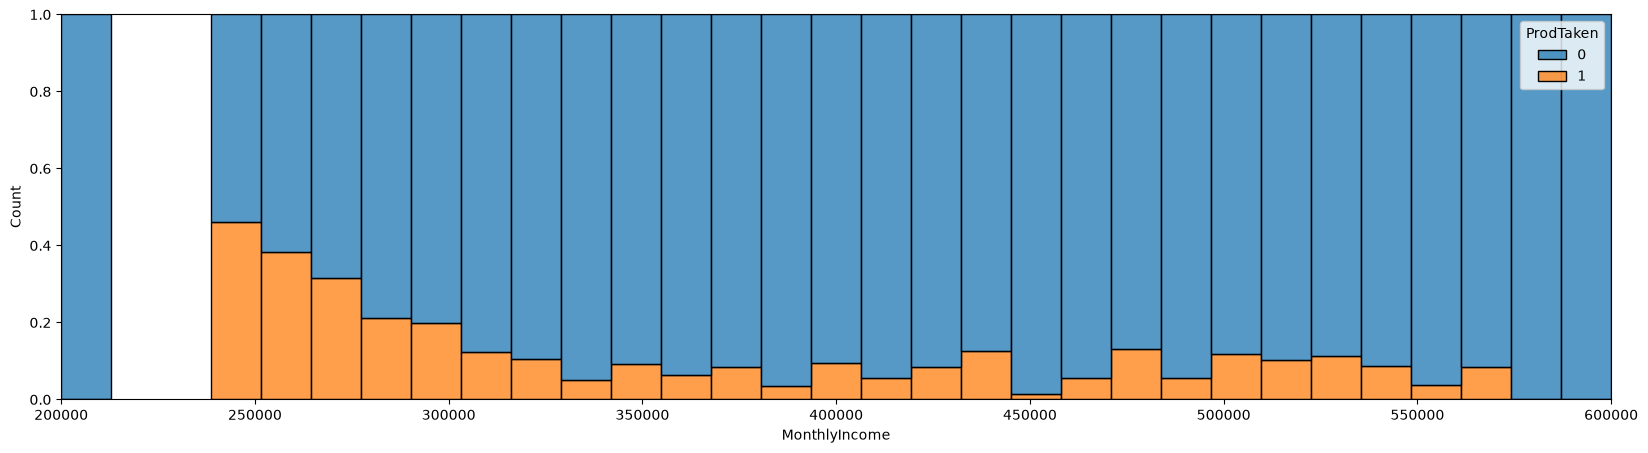

In [11]:
plt.figure(figsize=(20, 5))
sns.histplot(data=df, x='MonthlyIncome', hue='ProdTaken', multiple='fill')
plt.xticks()
plt.show()

* 成約のピークが月収25万～27万くらい
* 成約しなかったのが30万～35万くらい<br>
全体が多いのにもかかわらず成約できていない
* 中間管理職の方が多い可能性
（時間がないの可能性）

* 結果的に年収は関係があるがどちらかといえば役職や、
自分に時間があるかどうかが関係している可能性あり

### メモ
* 時間がある役職についているかついていないか